### Instructions: 
 - define model parameters, 
 - fit model to data to calibrate velocity scale, 
 - fit data and model to lorentzian, 
 - verify the are consistent

In [1]:
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer, _lorentzian_s
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"
#print_ironanalytics_metadata(directory)


In [ ]:
v = np.linspace(-8,8,1000)    

#SOURCE
sourceRh = CobaltRhodium ()
sourceRh.Gamma_ev = 7.65e-9
sourceRh.update_params()

#ABSORBER Alpha Fe
absorberAlpha = alphaFe()
absorberAlpha.thickness_m = 25e-6
absorberAlpha.abundance = 0.0212
absorberAlpha.update_params()


#ABSORBER A3
absorberA3 = alphaFe()
absorberA3.thickness_m = 600e-9

absorberA3.abundance = 0.96
absorberA3.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberA3.update_params()
#CALCULATIONS
moss_Alpha = Mossbauer(sourceRh, absorberAlpha)
moss_A3 = Mossbauer(sourceRh, absorberA3)

t_Alpha = moss_Alpha.total_transmission_rate(v)
t_A3 = moss_A3.total_transmission_rate(v)



In [4]:
directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"
["A00152","A00153","A00155"]

data_alphaFe = read_ironanalytics_data(directory, "A00156", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep102mms = read_ironanalytics_data(directory, "A00153", offset = -3, plot = False)
data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_alphaFeFesource = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)




## AlphaFe

A=1.335, s=1.263, x0=-0.150, B=0.615, C=0.461


Text(0, 0.5, 'Transmission')

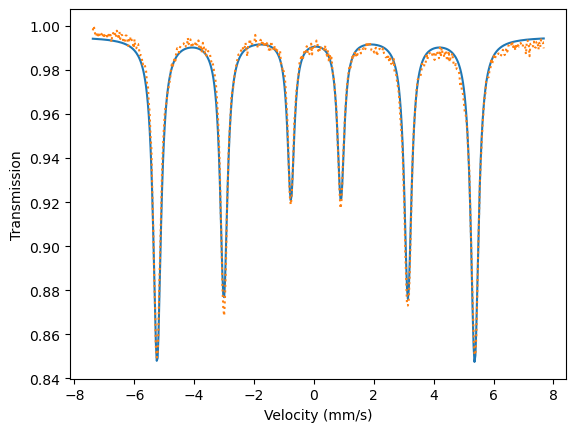

In [353]:
from scipy.interpolate import interp1d


# Model Data and interpolation function
x_model = v
y_model = t_Alpha

# Measured Data
x_meas = data_alphaFe.velocity_list
y_meas = data_alphaFe.data_folded/max(data_alphaFe.data_folded)


model_interp = interp1d(x_model, y_model, kind="cubic",
                        bounds_error=False,
                        fill_value=(y_model[0], y_model[-1]))

def model_fit_function(p, x):
    A, B, s, x0 = p
    return A * model_interp(s * (x - x0)) + B

p, dp = u.fit(model_fit_function, x_meas, y_meas, p0=[1,0.6,1.3,0.1], fullout=False)
A, B, s, x0 = p
C = B / A

x_calibrated = s * (x_meas - x0)
y_model_fit = model_fit_function(p, x_meas)



print(f"A={A:.3f}, s={s:.3f}, x0={x0:.3f}, B={B:.3f}, C={C:.3f}")

plt.plot(x_calibrated, y_model_fit, label='Alpha Fe Absorber')
plt.plot(x_calibrated, y_meas, label='Alpha Fe Data', linestyle='dotted')
plt.xlabel("Velocity (mm/s)")
plt.ylabel("Transmission")


Lorentzian fit to measurement: x0:5.373, Gamma:0.310, A:0.142, eta_nr:0.991
Lorentzian fit to model:       x0:5.370, Gamma:0.310, A:0.148, eta_nr:0.994
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.159+0.095 = 0.254 mm/s


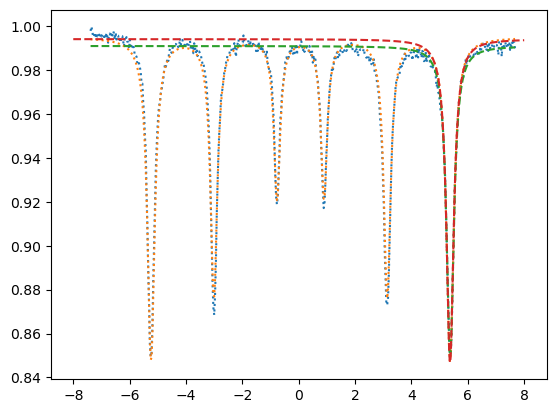

In [354]:

def lorentzian(p,x):
    x0, Gamma, A, eta_nr = p
    return eta_nr-A*(Gamma/2)**2 / ((x-x0)**2 + (Gamma/2)**2)

#now fit a lorentzian to see actual linewidth
#select limited vrange
idx0 = np.argmin(np.abs(x_calibrated - 4.3))
idx1 = np.argmin(np.abs(x_calibrated - 6.3))

x_section = x_calibrated[idx0:idx1]
y_section = y_meas[idx0:idx1]
y_model_section = y_model_fit[idx0:idx1]

p, dp = u.fit(lorentzian, x_section, y_section, p0=[5.5,0.2,-0.5,0], fullout=False)


print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")

plt.plot(x_calibrated, y_meas, label='Data', linestyle='dotted')
plt.plot(x_calibrated,  y_model_fit, label='Model', linestyle='dotted')
plt.plot(x_calibrated, lorentzian(p, x_calibrated), label='Lorentzian Fit to data', linestyle='--')

p, dp = u.fit(lorentzian, x_section, y_model_section, p0=p, fullout=False)

print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")

plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceRh.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceRh.Gamma + absorberAlpha.Gamma :.3f} mm/s")


(0.0, 1.05)

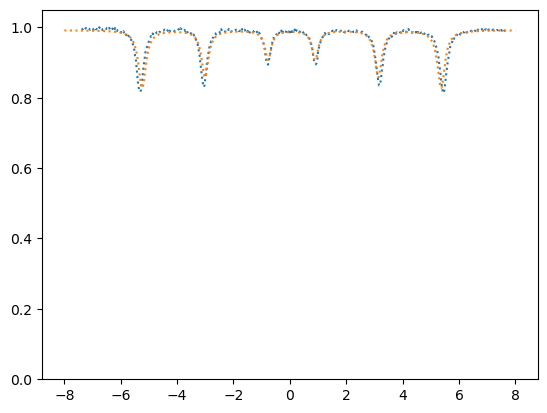

In [329]:
# Model Data and interpolation function
x_model = v
y_model = t_A3


B = 1.4
A = 0.99+B

# Measured Data
x_meas = data_dep10.velocity_list
y_meas = data_dep10.data_folded/max(data_dep10.data_folded)

plt.plot(x_calibrated, y_meas, label='Data', linestyle='dotted')
plt.plot(x_model, (y_model+B)/A, label='Model', linestyle='dotted')

plt.ylim(0.,1.05)

A=0.705, s=1.245, x0=-0.151, B=1.400, C=0.461


Text(0, 0.5, 'Transmission')

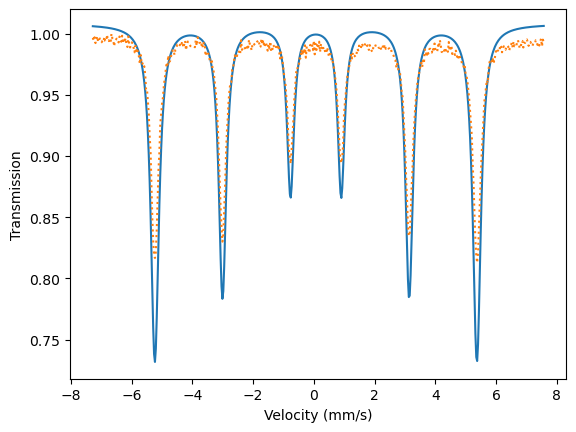

In [330]:
from scipy.interpolate import interp1d


# Model Data and interpolation function
x_model = v
y_model = t_A3

# Measured Data
x_meas = data_dep10.velocity_list
y_meas = data_dep10.data_folded/max(data_dep10.data_folded)


model_interp = interp1d(x_model, y_model, kind="cubic",
                        bounds_error=False,
                        fill_value=(y_model[0], y_model[-1]))

def model_fit_function(p, x):
    A, s, x0 = p
    return A * (model_interp(s * (x - x0)) + C)

p, dp = u.fit(model_fit_function, x_meas, y_meas, p0=[1,1.3,0.1], fullout=False)
A, s, x0 = p

x_calibrated = s * (x_meas - x0)
y_model_fit = model_fit_function(p, x_meas)



print(f"A={A:.3f}, s={s:.3f}, x0={x0:.3f}, B={B:.3f}, C={C:.3f}")

plt.plot(x_calibrated, y_model_fit, label='Alpha Fe Absorber')
plt.plot(x_calibrated, y_meas, label='Alpha Fe Data', linestyle='dotted')
plt.xlabel("Velocity (mm/s)")  
plt.ylabel("Transmission")


Lorentzian fit to measurement: x0:5.374, Gamma:0.305, A:0.180, eta_nr:0.993
Lorentzian fit to model:       x0:5.370, Gamma:0.315, A:0.276, eta_nr:1.006
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.159+0.095 = 0.254 mm/s


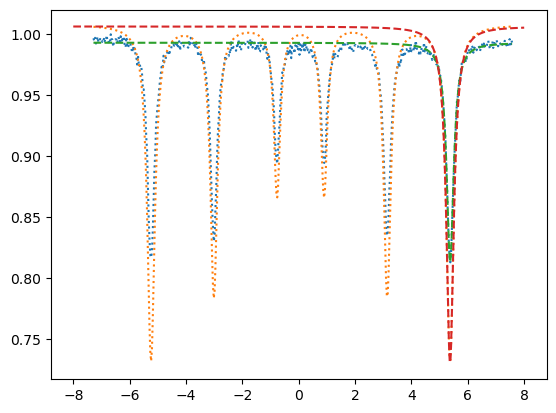

In [331]:

def lorentzian(p,x):
    x0, Gamma, A, eta_nr = p
    return eta_nr-A*(Gamma/2)**2 / ((x-x0)**2 + (Gamma/2)**2)

#now fit a lorentzian to see actual linewidth
#select limited vrange
idx0 = np.argmin(np.abs(x_calibrated - 4.3))
idx1 = np.argmin(np.abs(x_calibrated - 6.3))

x_section = x_calibrated[idx0:idx1]
y_section = y_meas[idx0:idx1]
y_model_section = y_model_fit[idx0:idx1]

p, dp = u.fit(lorentzian, x_section, y_section, p0=[5.5,0.2,-0.5,0], fullout=False)


print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")

plt.plot(x_calibrated, y_meas, label='Data', linestyle='dotted')
plt.plot(x_calibrated,  y_model_fit, label='Model', linestyle='dotted')
plt.plot(x_calibrated, lorentzian(p, x_calibrated), label='Lorentzian Fit to data', linestyle='--')

p, dp = u.fit(lorentzian, x_section, y_model_section, p0=p, fullout=False)

print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")

plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceRh.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceRh.Gamma + absorberAlpha.Gamma :.3f} mm/s")


In [7]:


def source_spectrum_matrix(Egrid, v, source):
    """
    Returns matrix shape (Nq, Nv): src(Egrid[k], v[i])
    """
    v = np.asarray(v)
    # broadcast: Egrid[:,None] and v[None,:]
    Emat = Egrid[:, None]
    vmat = v[None, :]

    spec = 0.0
    for coef, Eres in zip(source.transition_coefficients, source.Eres):
        # _lorentzian_s(x, x0, gamma) with x0 = Eres - v
        spec = spec + coef * _lorentzian_s(Emat, (Eres - vmat), source.Gamma)
    return source.fs * spec  # include recoilless fraction




from numpy.polynomial.legendre import leggauss
import numpy as np

Nq = 1600  # 200–800 is typical; sets precision of numerical integration
W = 20    # width of integration region in mm/s

xq, wq = leggauss(Nq)      # nodes/weights on [-1,1]
Egrid = W * xq             # energies on [-W, W]
Wgrid = W * wq             # weights for integral over [-W,W]





def S_fast(t, v, absorber, source):
    # update absorber thickness-dependent parameters
    absorber.thickness_m = float(t)
    absorber.update_params()

    moss = Mossbauer(source, absorber)

    # attenuation from resonant cross section on Egrid (1D)
    sigma = moss.cross_section(Egrid)  # includes sigma0 and Lorentzian_a sum
    tau = sigma * absorber.fa * absorber.nM * absorber.thickness_gcm2_Fe57
    att = np.exp(-tau)                 # shape (Nq,)

    # source spectrum matrix (Nq, Nv)
    src = source_spectrum_matrix(Egrid, v, source)

    # integral over Egrid: sum_k w_k * src_k,i * att_k
    resonant = (Wgrid[:, None] * (src * att[:, None])).sum(axis=0)

    # multiply by non-resonant attenuation of absorber (depends on thickness too)
    resonant *= moss.non_resonant_attenuation()

    # add non-resonant photons (flat in v)
    return moss.nonresonant_transmission_rate() + resonant


def S_slow(t, v, absorber, source):
    # update absorber thickness-dependent parameters
    
    absorber.thickness_m = float(t)
    absorber.update_params()
    moss = Mossbauer(source, absorber)

    return moss.total_transmission_rate(v)



In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# model grid (velocity axis of theory/model) and model values for a given t
# you will update y_model each t, but x_model is fixed
x_model =  np.linspace(-10,10,1000)

def profile_scan_t(xdata, ydata, t_grid, absorber, source):
    best = None
    best_all = []  # store results for plotting (chi2 vs t)

    for t in t_grid:
        # compute theory curve for this thickness on x_model
        y_model = S_fast(t, x_model, absorber, source)   # or S(t, x_model) if you keep quad_vec

        # interpolation of the model curve
        model_interp = interp1d(
            x_model, y_model,
            kind="cubic",
            bounds_error=False,
            fill_value=(y_model[0], y_model[-1])
        )

        # Fit parameters: A, B, x0, s
        def fit_model(p, x):
            A, B, x0, s = p
            return A * model_interp(s * (x - x0)) + B

        # initial guess (use previous best as warm start when available)
       
        p0 = [1.0, 1, 0.15, 1.3]
       
        p, dp = u.fit(fit_model, xdata, ydata, p0=p0, fullout=False)
        A, B, x0, s = p

        # compute SSE / chi^2-like score for this t
        r = ydata - fit_model(p, xdata)
        SSE = np.sum(r*r)

        rec = dict(t=t, A=A, B=B, x0=x0, s=s, SSE=SSE)
        best_all.append(rec)

        if (best is None) or (SSE < best["SSE"]):
            best = rec

    # optional: compute C = B/A
    best["C"] = best["B"] / best["A"] if best["A"] != 0 else np.nan
    return best, best_all

BEST:
{'t': 6.142857142857142e-07, 'A': 0.474483476737354, 'B': 0.5378640427361074, 'x0': -0.15133750642922242, 's': 1.2449530382784235, 'SSE': 0.007937613595417153, 'C': 1.1335780255923162}


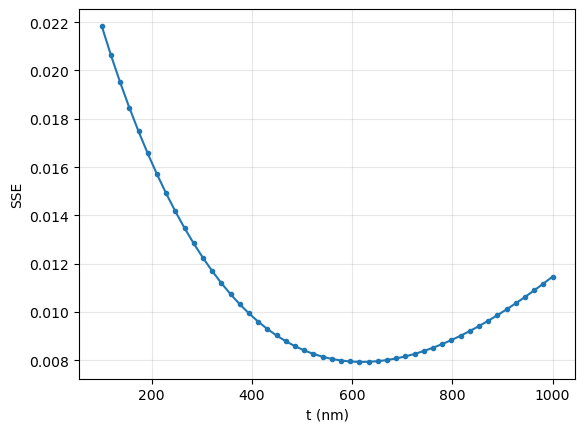

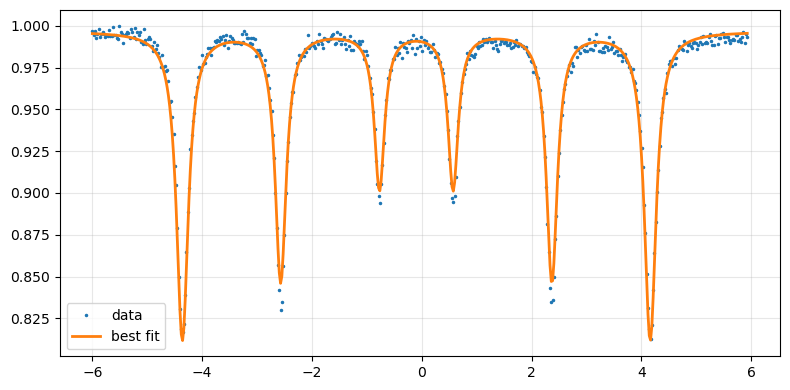

In [9]:
#SOURCE
source = CobaltRhodium ()
source.Eres = [-0.11] #from pipcorn
source.Gamma_ev = 7.9e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 1000e-9

absorber.abundance = 0.96
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()


x_meas = data_dep10.velocity_list
y_meas = data_dep10.data_folded/max(data_dep10.data_folded)
t_grid = np.linspace(100e-9, 1000e-9, 50)





best, all_fits = profile_scan_t(x_meas, y_meas, t_grid, absorber, source)

print("BEST:")
print(best)

# plot profile curve
plt.figure()
plt.plot([d["t"]*1e9 for d in all_fits], [d["SSE"] for d in all_fits], "-o", ms=3)
plt.xlabel("t (nm)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# plot best fit overlay
t_best = best["t"]
y_model_best = S_fast(t_best, x_model, absorber, source)
model_interp_best = interp1d(x_model, y_model_best, kind="cubic",
                             bounds_error=False, fill_value=(y_model_best[0], y_model_best[-1]))

def fit_model_best(x):
    return best["A"] * model_interp_best(best["s"] * (x - best["x0"])) + best["B"]

plt.figure(figsize=(8,4))
plt.plot(x_meas, y_meas, ".", ms=3, label="data")
plt.plot(x_meas, fit_model_best(x_meas), "-", lw=2, label="best fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
plt.plot(x_calibrated, S_fast(t_best, x_calibrated, absorber, source), label='Model', linestyle='dotted')
plt.plot(x_calibrated, S_slow(t_best, x_calibrated, absorber, source), label='Model', linestyle='dotted')

NameError: name 'x_calibrated' is not defined

BEST:
{'t': 1.7857142857142855e-07, 'A': 0.3332844331231373, 'B': 0.6686710796467852, 'x0': -0.003976643745954616, 's': 1.3850449388866597, 'SSE': 0.0013666132788065506, 'C': 2.0063075655253715}


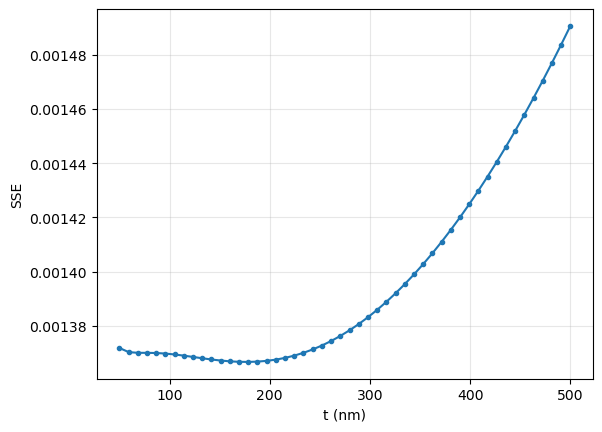

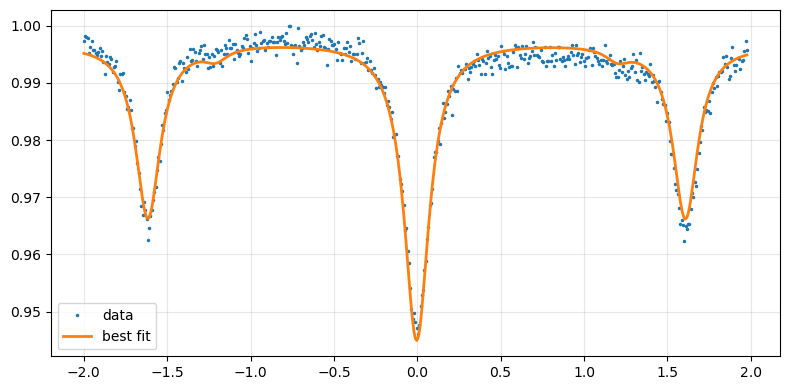

In [440]:
#SOURCE
source = CobaltFe ()
source.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
source.Gamma_ev = 6.75e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 1000e-9

absorber.abundance = 0.96
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()


x_meas = data_dep9.velocity_list
y_meas = data_dep9.data_folded/max(data_dep9.data_folded)
t_grid = np.linspace(50e-9, 500e-9, 50)





best, all_fits = profile_scan_t(x_meas, y_meas, t_grid, absorber, source)

print("BEST:")
print(best)

# plot profile curve
plt.figure()
plt.plot([d["t"]*1e9 for d in all_fits], [d["SSE"] for d in all_fits], "-o", ms=3)
plt.xlabel("t (nm)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# plot best fit overlay
t_best = best["t"]
y_model_best = S_fast(t_best, x_model, absorber, source)
model_interp_best = interp1d(x_model, y_model_best, kind="cubic",
                             bounds_error=False, fill_value=(y_model_best[0], y_model_best[-1]))

def fit_model_best(x):
    return best["A"] * model_interp_best(best["s"] * (x - best["x0"])) + best["B"]

plt.figure(figsize=(8,4))
plt.plot(x_meas, y_meas, ".", ms=3, label="data")
plt.plot(x_meas, fit_model_best(x_meas), "-", lw=2, label="best fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

BEST:
{'t': 2.887755102040816e-07, 'A': 0.303250515054787, 'B': 0.7005012848501785, 'x0': -0.0026874818948730917, 's': 1.3815335880051327, 'SSE': 0.0007919826697587511, 'C': 2.3099755814878726}


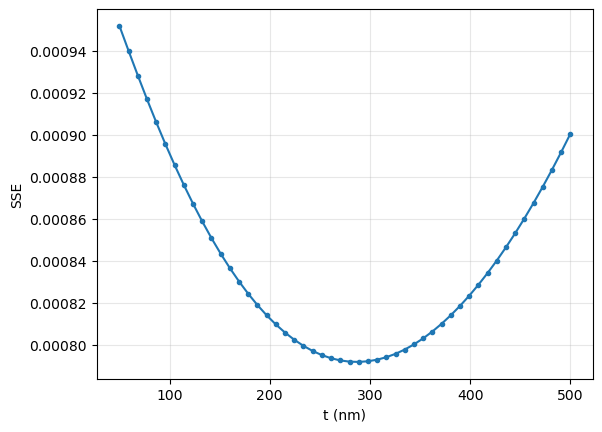

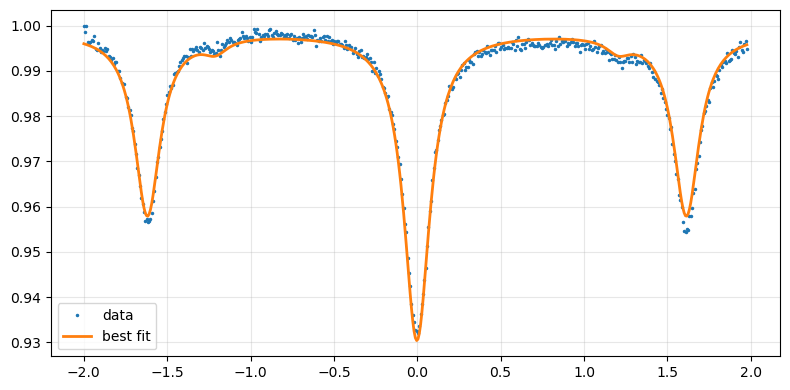

In [11]:
#SOURCE
source = CobaltFe ()
source.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
source.Gamma_ev = 6.75e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 1000e-9

absorber.abundance = 0.96
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()


x_meas = data_dep8.velocity_list
y_meas = data_dep8.data_folded/max(data_dep8.data_folded)
t_grid = np.linspace(50e-9, 500e-9, 50)





best, all_fits = profile_scan_t(x_meas, y_meas, t_grid, absorber, source)

print("BEST:")
print(best)

# plot profile curve
plt.figure()
plt.plot([d["t"]*1e9 for d in all_fits], [d["SSE"] for d in all_fits], "-o", ms=3)
plt.xlabel("t (nm)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# plot best fit overlay
t_best = best["t"]
y_model_best = S_fast(t_best, x_model, absorber, source)
model_interp_best = interp1d(x_model, y_model_best, kind="cubic",
                             bounds_error=False, fill_value=(y_model_best[0], y_model_best[-1]))

def fit_model_best(x):
    return best["A"] * model_interp_best(best["s"] * (x - best["x0"])) + best["B"]

plt.figure(figsize=(8,4))
plt.plot(x_meas, y_meas, ".", ms=3, label="data")
plt.plot(x_meas, fit_model_best(x_meas), "-", lw=2, label="best fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

BEST:
{'t': 2.5714285714285714e-05, 'A': 1.1327574688628785, 'B': 0.691820479380859, 'x0': -0.004103921817696544, 's': 1.3719825818999627, 'SSE': 0.0005487220363868433, 'C': 0.6107401614180878}


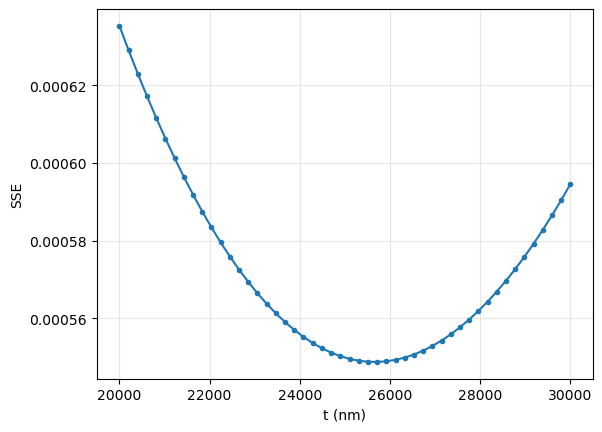

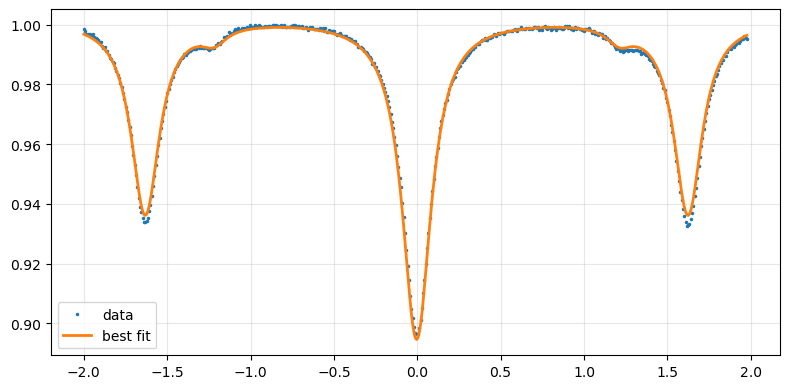

In [12]:
data_alphaFeFesource


#SOURCE
source = CobaltFe ()
source.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
source.Gamma_ev = 6.85e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 1000e-9

absorber.abundance = 0.0212
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()


x_meas = data_alphaFeFesource.velocity_list
y_meas = data_alphaFeFesource.data_folded/max(data_alphaFeFesource.data_folded)
t_grid = np.linspace(20e-6, 30e-6, 50)





best, all_fits = profile_scan_t(x_meas, y_meas, t_grid, absorber, source)

print("BEST:")
print(best)

# plot profile curve
plt.figure()
plt.plot([d["t"]*1e9 for d in all_fits], [d["SSE"] for d in all_fits], "-o", ms=3)
plt.xlabel("t (nm)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# plot best fit overlay
t_best = best["t"]
y_model_best = S_fast(t_best, x_model, absorber, source)
model_interp_best = interp1d(x_model, y_model_best, kind="cubic",
                             bounds_error=False, fill_value=(y_model_best[0], y_model_best[-1]))

def fit_model_best(x):
    return best["A"] * model_interp_best(best["s"] * (x - best["x0"])) + best["B"]

plt.figure(figsize=(8,4))
plt.plot(x_meas, y_meas, ".", ms=3, label="data")
plt.plot(x_meas, fit_model_best(x_meas), "-", lw=2, label="best fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

BEST:
{'t': 2.795918367346939e-05, 'A': 1.3930905033191472, 'B': 0.6534383446484273, 'x0': -0.1502691494492461, 's': 1.2625610818978683, 'SSE': 0.0045679350272749735, 'C': 0.4690566356540076}


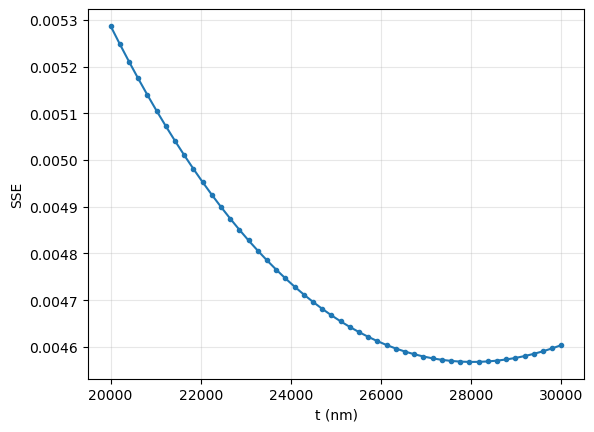

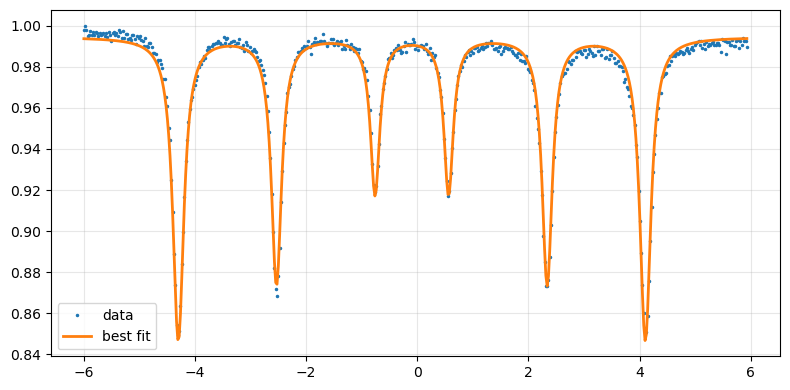

In [13]:

#SOURCE
source = CobaltRhodium ()
source.Eres = [-0.11] #from pipcorn
source.Gamma_ev = 6.8e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6

absorber.abundance = 0.0212
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()

#DATA
x_meas = data_alphaFe.velocity_list
y_meas = data_alphaFe.data_folded/max(data_alphaFe.data_folded)



t_grid = np.linspace(20e-6, 30e-6, 50)
best, all_fits = profile_scan_t(x_meas, y_meas, t_grid, absorber, source)

print("BEST:")
print(best)

# plot profile curve
plt.figure()
plt.plot([d["t"]*1e9 for d in all_fits], [d["SSE"] for d in all_fits], "-o", ms=3)
plt.xlabel("t (nm)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# plot best fit overlay
t_best = best["t"]
y_model_best = S_fast(t_best, x_model, absorber, source)
model_interp_best = interp1d(x_model, y_model_best, kind="cubic",
                             bounds_error=False, fill_value=(y_model_best[0], y_model_best[-1]))

def fit_model_best(x):
    return best["A"] * model_interp_best(best["s"] * (x - best["x0"])) + best["B"]

plt.figure(figsize=(8,4))
plt.plot(x_meas, y_meas, ".", ms=3, label="data")
plt.plot(x_meas, fit_model_best(x_meas), "-", lw=2, label="best fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'SSE')

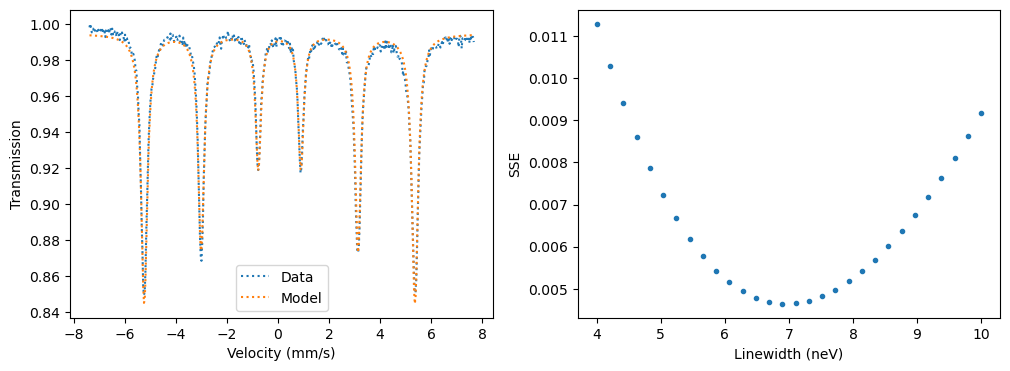

In [14]:
from mossbauer_analysis.mossbauer_fit_model import optimize_linewidth_s, optimize_thickness


#SOURCE
source = CobaltRhodium ()
source.Eres = [-0.11] #from pipcorn
source.Gamma_ev = 7.e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6

absorber.abundance = 0.0212
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()

#DATA
x_data = data_alphaFe.velocity_list
y_data = data_alphaFe.data_folded/max(data_alphaFe.data_folded)

gamma_s_grid = np.linspace(4e-9, 1e-8, 30)
x_model = np.linspace(-10,10,1000)

best, sse, x_calibrated, y_model, y_fit = optimize_linewidth_s(x_data, y_data, gamma_s_grid, absorber, source, x_model, fast=False)

#best, sse, x_calibrated, y_model, y_fit = optimize_thickness(x_data, y_data, t_grid, absorber, source, x_model, fast=True, Nq=1600, W=20)

#print(f"Best fit: thickness={best['t']*1e9:.3f} nm, SSE={sse:.3e}")

fig, ax = plt.subplots(1,2, figsize=(12,4))


ax[0].plot(x_calibrated, y_data, label='Data', linestyle='dotted')
ax[0].plot(x_calibrated, y_fit, label='Model', linestyle='dotted')  
ax[0].set_xlabel("Velocity (mm/s)")
ax[0].set_ylabel("Transmission")
ax[0].legend()

# Plot SSE vs linewidth
ax[1].plot(gamma_s_grid*1e9, sse,'.')
ax[1].set_xlabel("Linewidth (neV)")
ax[1].set_ylabel("SSE")

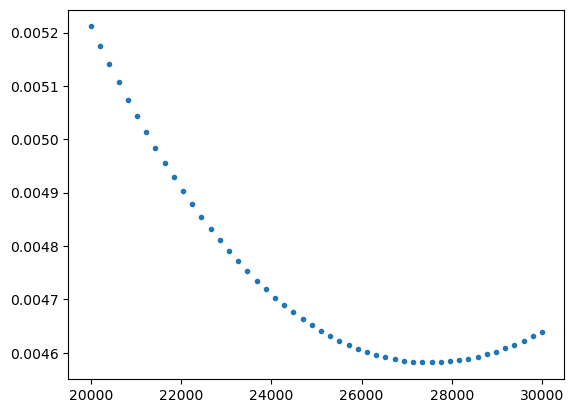

In [15]:

source.Gamma_ev = best["gamma_s"]
source.update_params()
best, sse, x_calibrated, y_model, y_fit = optimize_thickness(x_data, y_data, t_grid, absorber, source, x_model, fast=False)

plt.plot( t_grid*1e9, sse,'.')

In [16]:
best

{'t': 2.7551020408163265e-05,
 'A': 1.382761974809601,
 'B': 0.6483051598413838,
 'x0': -0.15026443108837068,
 's': 1.2625650144216882,
 'SSE': 0.004581647322930961}